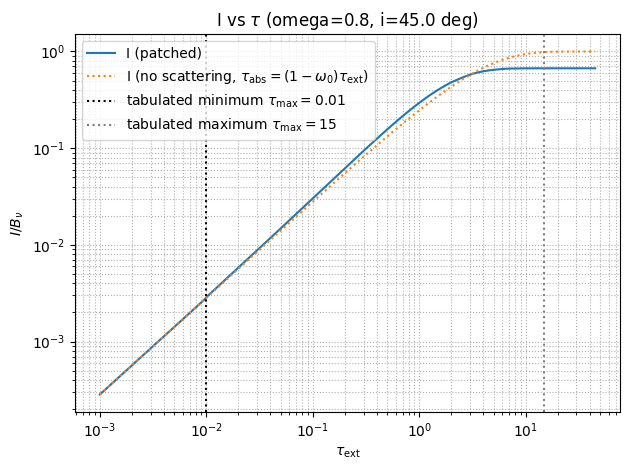

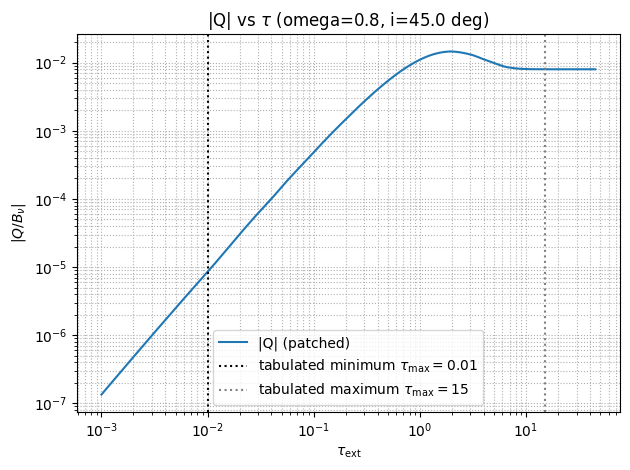

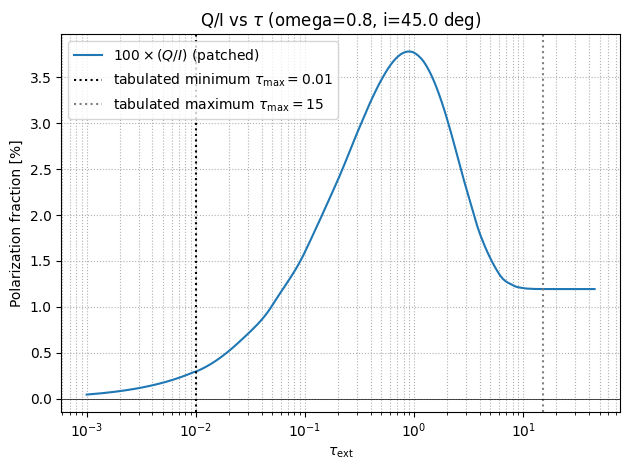

In [4]:
from emergentintensity import emergent_stokes, INTERP_TABLES, interpolate_stokes, analytic_thin_I_scalar

import numpy as np
import matplotlib.pyplot as plt

# Parameters
omega0 = 0.8
inc0   = 45.0

# tau-grid from the interpolation tables
tau_min_table = float(INTERP_TABLES["tau_grid"][0])
tau_max_table = float(INTERP_TABLES["tau_grid"][-1])

# tau_ext grid for plotting (extend a bit beyond the maximum tabulated tau)
tau_vals = np.logspace(-3, np.log10(tau_max_table * 3.0), 200)

I_pure,  Q_pure  = [], []
I_patch, Q_patch = [], []
PF_patch = []  # computed as Q/I from patched outputs
I_abs    = []  # “no scattering” reference with tau_abs = (1 - omega0) * tau_ext

for t in tau_vals:
    # t is tau_ext (total extinction optical depth including scattering)

    # --- pure RT (table interpolation only, no patches) ---
    # interpolate_stokes returns (I, Q)
    I0, Q0 = interpolate_stokes(t, omega0, inc0)
    I_pure.append(float(I0))
    Q_pure.append(float(Q0))

    # --- patched version (emergent_stokes) ---
    # emergent_stokes returns (I, Q)
    I1, Q1 = emergent_stokes(t, omega0, inc0)
    I_patch.append(float(I1))
    Q_patch.append(float(Q1))
    PF_patch.append(0.0 if float(I1) == 0.0 else float(Q1) / float(I1))

    # --- “no scattering” reference:
    #     use tau_abs = (1 - omega0) * tau_ext for a purely absorbing slab ---
    tau_abs = t * (1.0 - omega0)  # effective absorption optical depth
    # analytic_thin_I_scalar(tau_max, omega, inc_deg)
    # here we treat tau_abs as "tau_max" with omega=0
    I_abs_val = analytic_thin_I_scalar(tau_abs, 0.0, inc0)
    I_abs.append(float(I_abs_val))

I_pure  = np.array(I_pure)
Q_pure  = np.array(Q_pure)

I_patch  = np.array(I_patch)
Q_patch  = np.array(Q_patch)
PF_patch = np.array(PF_patch)
I_abs    = np.array(I_abs)

# ----------------------------------
# I (patched vs no-scattering reference)
# ----------------------------------
plt.figure()
# plt.loglog(tau_vals, I_pure,  label="I (pure RT interpolation)")
plt.loglog(tau_vals, I_patch, "-", label="I (patched)")
plt.loglog(
    tau_vals,
    I_abs,
    ":",
    label=r"I (no scattering, $\tau_{\rm abs}=(1-\omega_0)\tau_{\rm ext}$)",
)

plt.axvline(
    tau_min_table,
    color="k",
    ls=":",
    label=fr"tabulated minimum $\tau_{{\max}}={tau_min_table:g}$",
)
plt.axvline(
    tau_max_table,
    color="gray",
    ls=":",
    label=fr"tabulated maximum $\tau_{{\max}}={tau_max_table:g}$",
)

plt.xlabel(r"$\tau_{\rm ext}$")
plt.ylabel(r"$I/B_\nu$")
plt.title(fr"I vs $\tau$ (omega={omega0}, i={inc0} deg)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()

# ----------------------------------
# Q (absolute value in log scale)
# ----------------------------------
plt.figure()
# plt.loglog(tau_vals, np.abs(Q_pure),  label="|Q| (pure RT interpolation)")
plt.loglog(tau_vals, np.abs(Q_patch), "-", label="|Q| (patched)")

plt.axvline(
    tau_min_table,
    color="k",
    ls=":",
    label=fr"tabulated minimum $\tau_{{\max}}={tau_min_table:g}$",
)
plt.axvline(
    tau_max_table,
    color="gray",
    ls=":",
    label=fr"tabulated maximum $\tau_{{\max}}={tau_max_table:g}$",
)

plt.xlabel(r"$\tau_{\rm ext}$")
plt.ylabel(r"$|Q/B_\nu|$")
plt.title(fr"|Q| vs $\tau$ (omega={omega0}, i={inc0} deg)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()

# ----------------------------------
# "PF" (= Q/I) (signed polarization fraction, x-axis in log scale)
# ----------------------------------
plt.figure()
plt.semilogx(tau_vals, 100.0 * PF_patch, "-", label=r"$100\times(Q/I)$ (patched)")

plt.axvline(
    tau_min_table,
    color="k",
    ls=":",
    label=fr"tabulated minimum $\tau_{{\max}}={tau_min_table:g}$",
)
plt.axvline(
    tau_max_table,
    color="gray",
    ls=":",
    label=fr"tabulated maximum $\tau_{{\max}}={tau_max_table:g}$",
)

plt.axhline(0.0, color="k", lw=0.5)
plt.xlabel(r"$\tau_{\rm ext}$")
plt.ylabel("Polarization fraction [%]")
plt.title(fr"Q/I vs $\tau$ (omega={omega0}, i={inc0} deg)")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()